## MTG  features vs TMRM features

In [2]:
# %pip install pandas
# %pip install seaborn
# %pip install numpy

In [3]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot
import numpy as np

# Layout

# Data Processing

In [4]:
# Global variables - CHANGE THESE
feature = "Mitochondria Intensity - Nucleus region Mean"
secondary_feature = "Mitochondria Intensity - Nucleus region CV [%]"
category = "Cellline ID"
data_path_tmrm = 'data/Raw_Data_Batch1_LAB2_CTX2.csv'
data_path_mtg = 'data/Raw_Data_Batch1_LAB1_CTX2.csv'

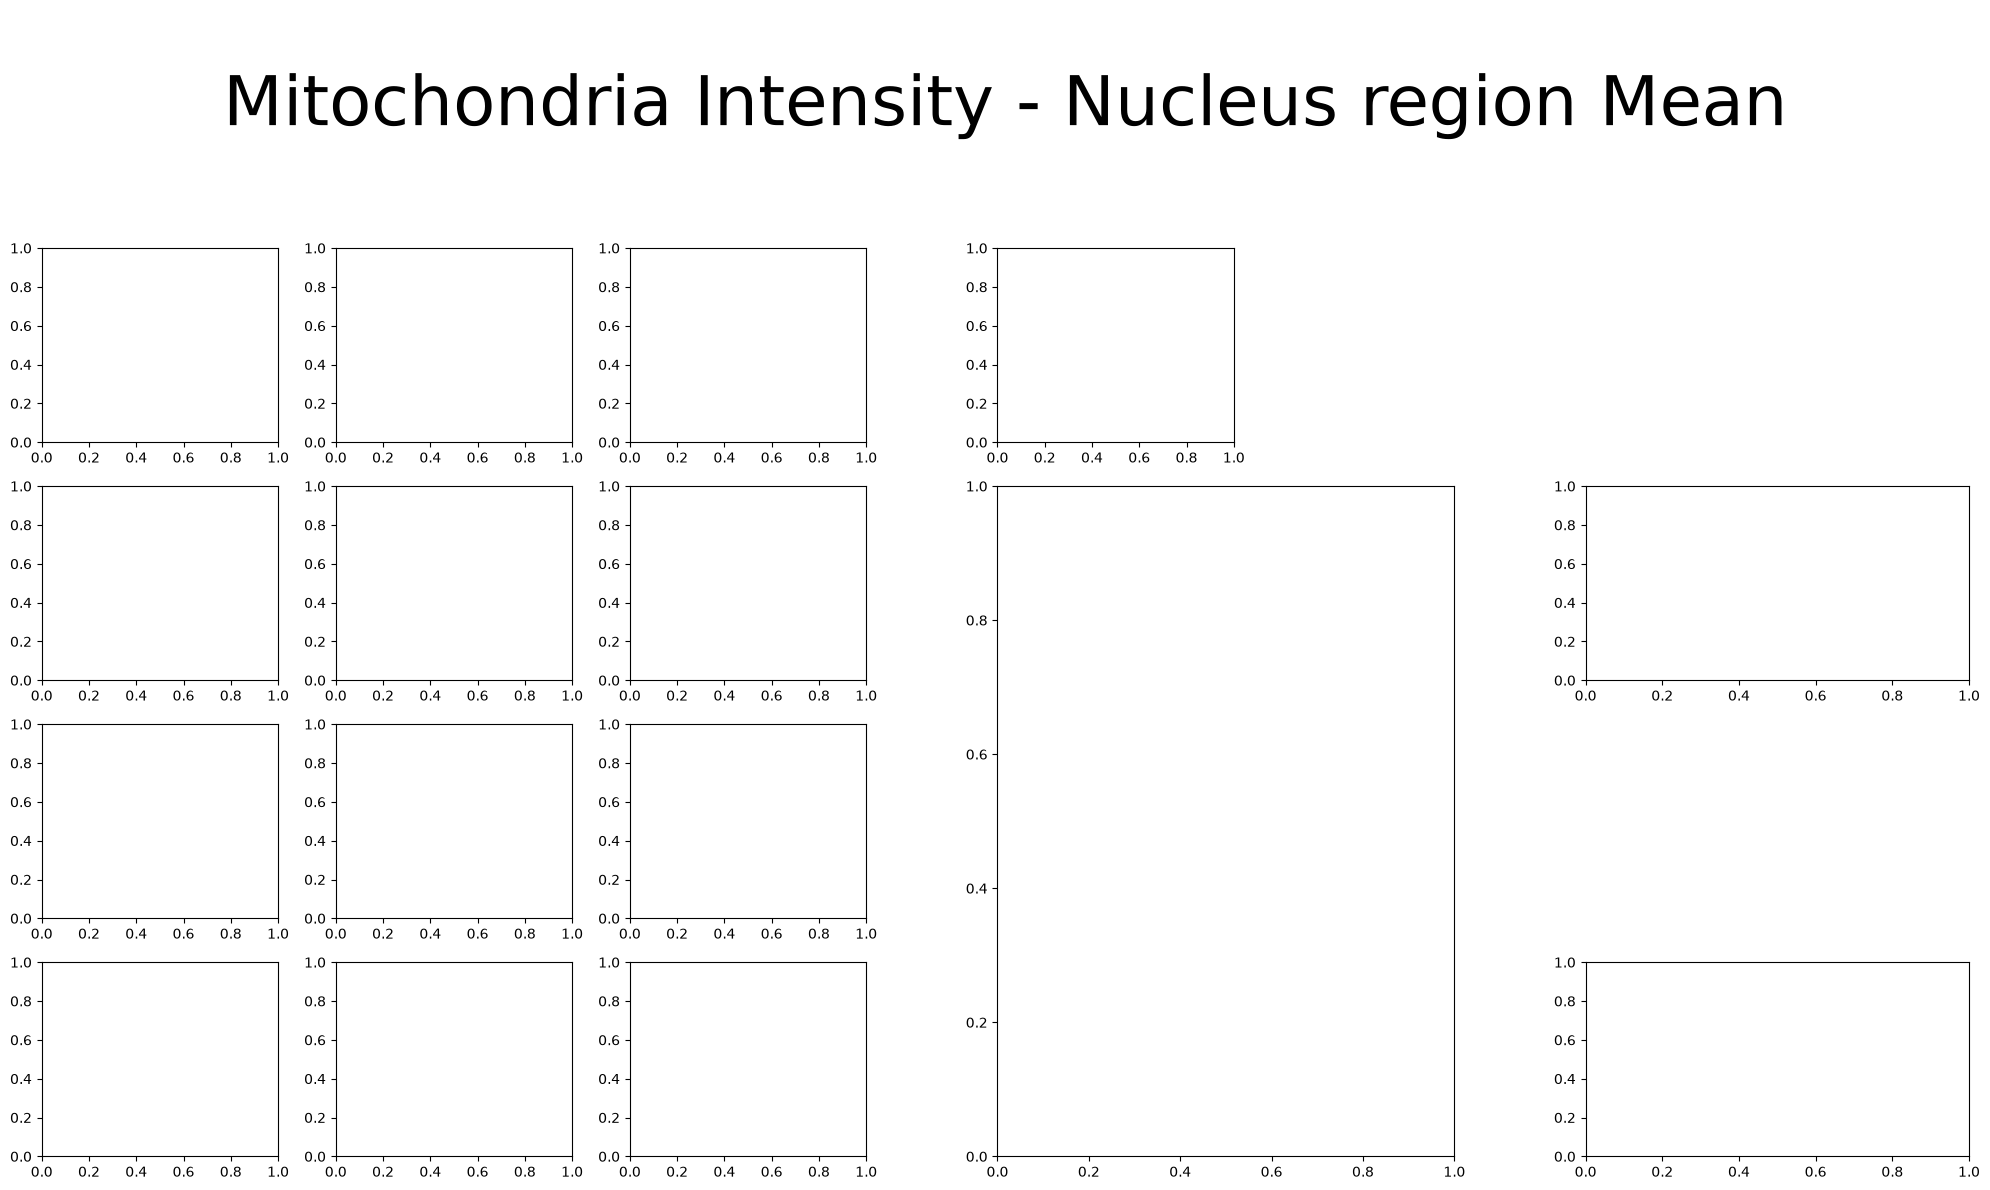

In [5]:
# # 1. Define complex layout using text characters.
# # Each letter represents a distinct plot area. 
# # Repeating a letter makes that plot span multiple rows/columns.

layout = """
    000000000000000000000000000
    LLLLEEEEHHHHVIIIITTTTTTTTTT
    QQQQRRRRSSSSVAAAAAAAZBBBBBB
    KKKKCCCCFFFFVAAAAAAAZ999999
    JJJJDDDDGGGGVAAAAAAAZ222222
"""

fig, axes = pyplot.subplot_mosaic(layout, figsize=(20, 12))

# # 2. Add text title to the top left (Area '0')
axes['0'].axis('off') # Hide grid lines
axes['0'].text(0.5, 0.5, feature, 
               fontsize=50, ha='center', va='center')
axes['Z'].axis('off') # Hide grid lines
axes['V'].axis('off') # Hide grid lines
axes['9'].axis('off') # Hide grid lines

# 3. Assign Seaborn plots to specific axes
# sns.histplot(data=df, x='...', ax=axes['A']) 
# sns.boxplot(data=df, x='...', y='...', ax=axes['B'])

# Example: The grid of small histograms (Areas L, E, H, I, Q, R, etc.)
# sns.histplot(..., ax=axes['B'])

# 4. Add Pandas DataFrame as a table (Area 'T')
axes['T'].axis('tight')
axes['T'].axis('off')

# table = axes['T'].table(cellText=summary_df.values,
#                         colLabels=summary_df.columns,
#                         loc='center',
#                         cellLoc='center')
# table.scale(1, 1.5) # Adjust table sizing

pyplot.tight_layout()

def identify_axes(ax_dict, fontsize=48):
    """
    Helper to identify the Axes in the examples below.

    Draws the label in a large font in the center of the Axes.

    Parameters
    ----------
    ax_dict : dict[str, Axes]
        Mapping between the title / label and the Axes.
    fontsize : int, optional
        How big the label should be.
    """
    kw = dict(ha="center", va="center", fontsize=fontsize, color="darkgrey")
    for k, ax in ax_dict.items():
        ax.text(0.5, 0.5, k, transform=ax.transAxes, **kw)


# ax_dict = fig.subplot_mosaic(layout)
# identify_axes(ax_dict)

In [6]:
tmrm_df = pd.read_csv(data_path_tmrm)
tmrm_df = tmrm_df[[feature, 
                   secondary_feature,
                    'Cell Type',
                     'Cellline ID']]
tmrm_df.head()

,Mitochondria Intensity - Nucleus region Mean,Mitochondria Intensity - Nucleus region CV [%],Cell Type,Cellline ID
0,397.515,20.43050,Control,RM3.5
1,965.883,20.33250,Control,RM3.5
2,313.914,25.11340,Control,RM3.5
3,265.610,7.57676,Control,RM3.5
4,321.283,10.23540,Control,RM3.5


In [7]:
mtg_df = pd.read_csv(data_path_mtg)
mtg_df = mtg_df[[feature,
                 secondary_feature,
                 'Cell Type',
                 'Cellline ID']]
mtg_df.head()

,Mitochondria Intensity - Nucleus region Mean,Mitochondria Intensity - Nucleus region CV [%],Cell Type,Cellline ID
0,3207.96,76.5629,Control,RM3.5
1,3371.44,54.1483,Control,RM3.5
2,14705.30,53.0572,Control,RM3.5
3,8035.14,58.1479,Control,RM3.5
4,12623.20,52.9985,Control,RM3.5


In [8]:
def calculate_percentiles(df, percentile_metric, feature_name):
    percentile_value = 1
    if percentile_metric == 'P5':
        percentile_value = 5
    elif percentile_metric == 'P25':
        percentile_value = 25
    elif percentile_metric == 'P50':
        percentile_value = 50
    elif percentile_metric == 'P75':
        percentile_value = 75
    elif percentile_metric == 'P95':
        percentile_value = 95
    elif percentile_metric == 'P99':
        percentile_value = 99
    else:
        percentile_value = 80
    
    percentile = np.percentile(df[[feature_name]],
                               percentile_value)
    
    return percentile

In [9]:
def create_cat_plot(df, feature_name, category):
    global axes
    global feature

    selected_cols_df = df[[feature_name, category]]

    # Only the get the values that are lower than P99 
    # to remove outliers
    P95 = calculate_percentiles(selected_cols_df,
                                'P95',
                                feature_name)

    selected_cols_df  = selected_cols_df[selected_cols_df[feature_name] < P95]
    control_cols = selected_cols_df[selected_cols_df[category] == 'Control']
    control_stats = control_cols.describe()
    control_median = control_stats.loc['50%', feature_name]
    boxplot = None
    custom_palette = {
        "Control": "#a8cdd9", # Light blue
        "LRRK2": "#e28725",   # Orange
        "PRKN": "#a3e49b",    # Light green
        "SNCA": "#e12827"     # Red
    }
    # WARNING
    if feature_name == secondary_feature:
        boxplot = sns.boxplot(
                    data=selected_cols_df,
                    x=feature_name,
                    y="Cell Type",
                    palette=custom_palette,
                    order=["Control", "LRRK2", "PRKN", "SNCA"],
                    linewidth=1.2,
                    fliersize=5,
                    flierprops={"marker": "d", "markerfacecolor": "#555555", "markeredgecolor": "#555555"},
                    ax=axes["2"]
                )
        # boxplot = sns.catplot(data=selected_cols_df, x=feature_name, y="Cell Type", kind="box", hue=category, palette=["lightblue", "darkorange", "lightgreen", "red"], ax=axes['2'])
    elif feature_name == feature:
        # boxplot = sns.catplot(data=selected_cols_df, x=feature_name, y="Cell Type", kind="box", hue=category, palette=["lightblue", "darkorange", "lightgreen", "red"], ax=axes['B'])
        boxplot = sns.boxplot(
                    data=selected_cols_df,
                    x=feature_name,
                    y="Cell Type",
                    palette=custom_palette,
                    order=["Control", "LRRK2", "PRKN", "SNCA"],
                    linewidth=1.2,
                    fliersize=5,
                    flierprops={"marker": "d", "markerfacecolor": "#555555", "markeredgecolor": "#555555"},
                    ax=axes["B"]
                )
    else:
        boxplot = sns.boxplot(
                    data=selected_cols_df,
                    x=feature_name,
                    y="Cell Type",
                    palette=custom_palette,
                    order=["Control", "LRRK2", "PRKN", "SNCA"],
                    linewidth=1.2,
                    fliersize=5,
                    flierprops={"marker": "d", "markerfacecolor": "#555555", "markeredgecolor": "#555555"}
                )
        
    boxplot.axvline(
        x=control_median,
        linewidth=1,
        ls='dotted',
        color='blue'
    )

    boxplot.text(x=control_median + 0.5, 
                        y=0.9, 
                        s=f"Median: {control_median:.1f}", 
                        color='blue', 
                        rotation=0,
                        transform=boxplot.get_xaxis_transform())
    
    # boxplot.fig.suptitle(feature_name)
    return boxplot

# Box Plot for MTG

In [10]:
mtg_box_plot = create_cat_plot(
    mtg_df,
    feature,
    'Cell Type'
)

/tmp/ipykernel_216528/971238987.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


In [11]:
mtg_box_plot_cv = create_cat_plot(
    mtg_df,
    secondary_feature,
    'Cell Type'
)

/tmp/ipykernel_216528/971238987.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


# Box Plot for TMRM

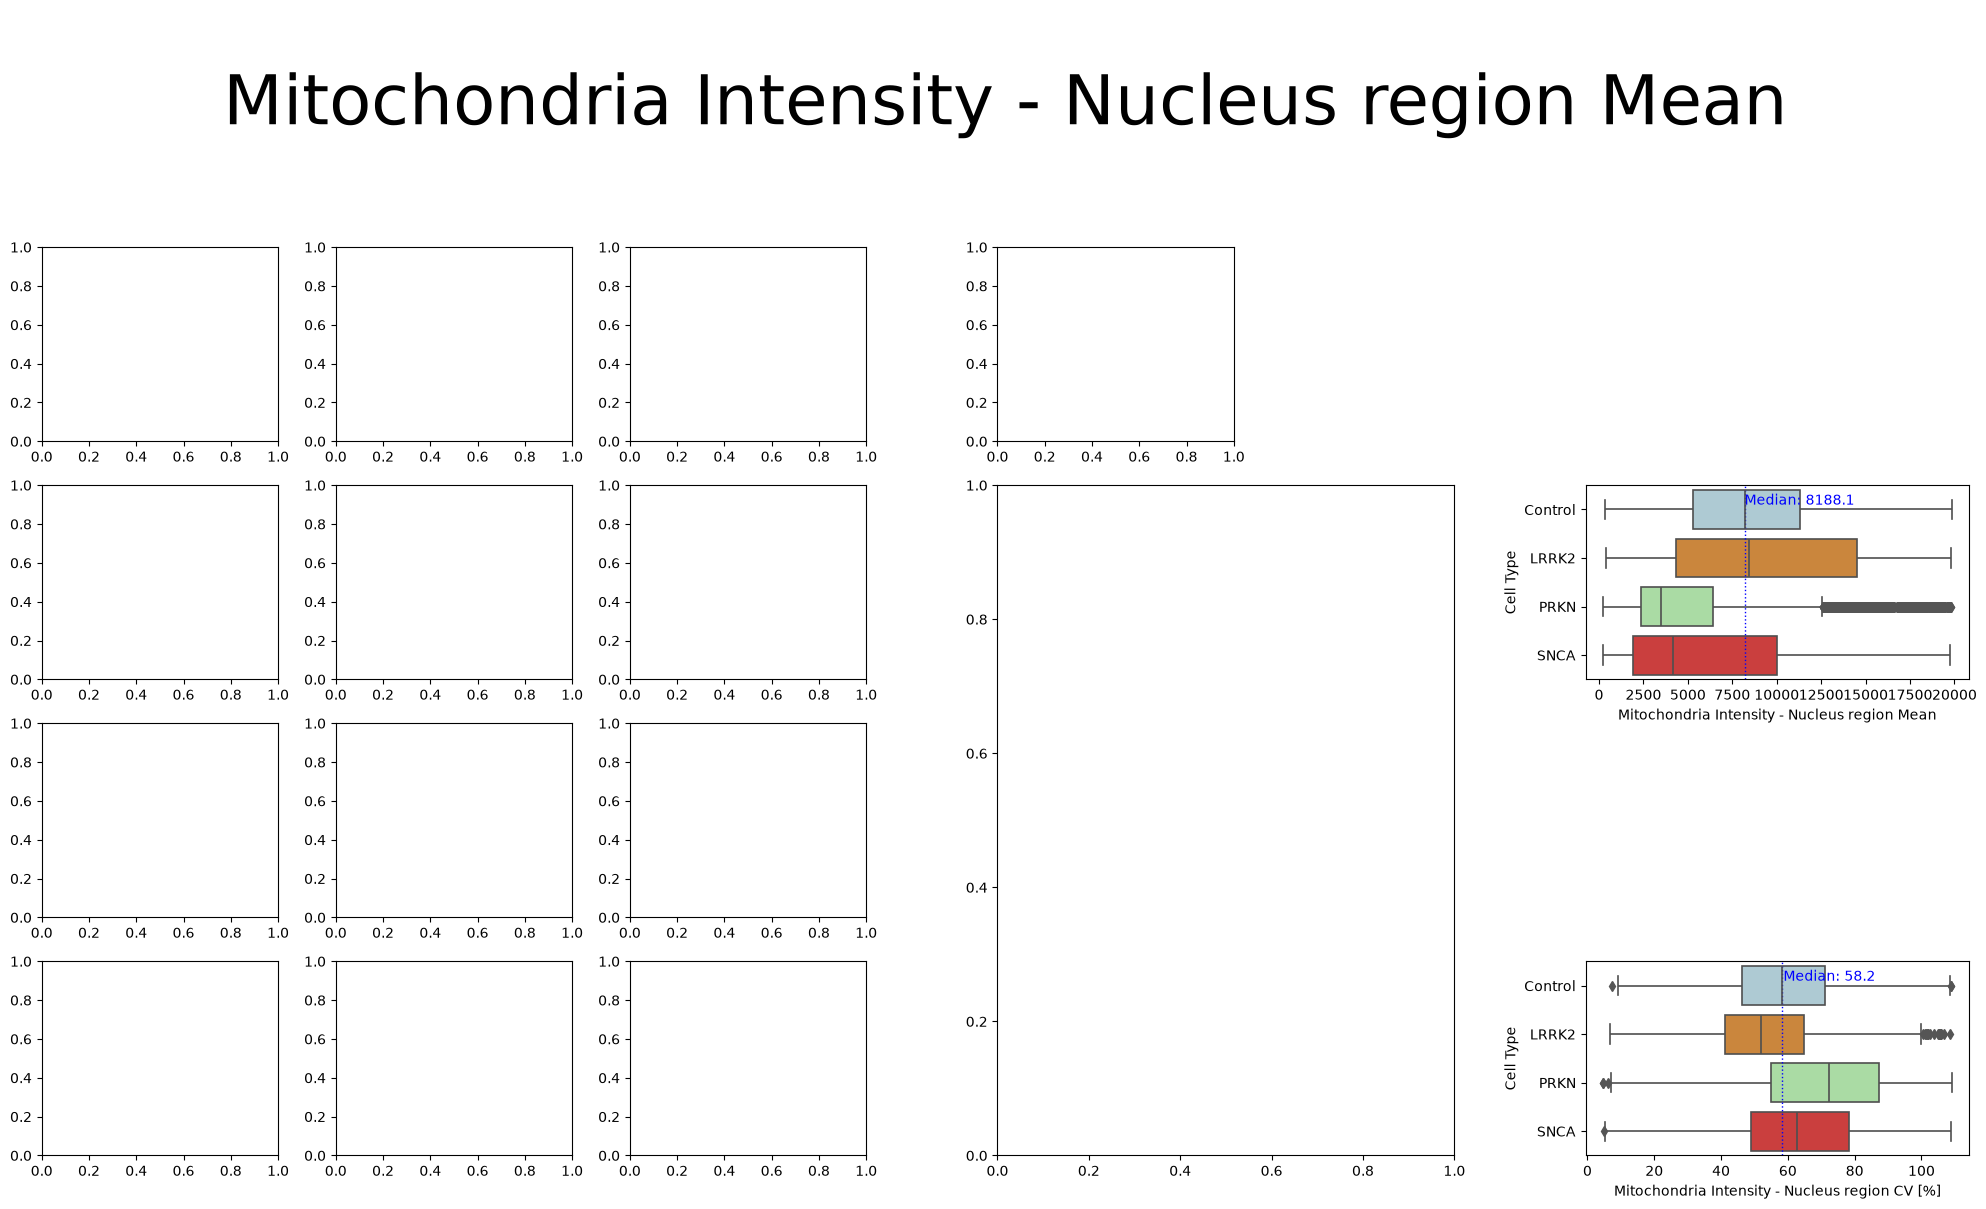

In [12]:
fig

### t-SNE visualisation

In [13]:
# %pip install scikit-learn
# %pip install plotly

In [14]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.express as px


In [15]:
tmrm_df = pd.read_csv(data_path_tmrm)
tmrm_df = tmrm_df[["Mitochondria Intensity - Nucleus region CV [%]", 
                   "Mitochondria Intensity - Inner region CV [%]",
                   "Mitochondria Intensity - Middle region CV [%]",
                   "Mitochondria Intensity - Outer region CV [%]",
                   "Mitochondria Intensity - Cell region CV [%]",
                   "Mitochondria Intensity - Nucleus region Mean", 
                   "Mitochondria Intensity - Inner region Mean",
                   "Mitochondria Intensity - Middle region Mean",
                   "Mitochondria Intensity - Outer region Mean",
                   "Mitochondria Intensity - Cell region Mean",
                    'Cell Type']]
tmrm_df = tmrm_df.dropna()
tmrm_df = tmrm_df[tmrm_df['Cell Type'] != 'Control']

X = tmrm_df[["Mitochondria Intensity - Nucleus region CV [%]", 
                   "Mitochondria Intensity - Inner region CV [%]",
                   "Mitochondria Intensity - Middle region CV [%]",
                   "Mitochondria Intensity - Outer region CV [%]",
                   "Mitochondria Intensity - Cell region CV [%]",
                   "Mitochondria Intensity - Nucleus region Mean", 
                   "Mitochondria Intensity - Inner region Mean",
                   "Mitochondria Intensity - Middle region Mean",
                   "Mitochondria Intensity - Outer region Mean",
                   "Mitochondria Intensity - Cell region Mean"]]
y = tmrm_df[['Cell Type']]

In [16]:
X.isna().sum()
X = X.dropna()
X.isna().sum()

Mitochondria Intensity - Nucleus region CV [%]    0
Mitochondria Intensity - Inner region CV [%]      0
Mitochondria Intensity - Middle region CV [%]     0
Mitochondria Intensity - Outer region CV [%]      0
Mitochondria Intensity - Cell region CV [%]       0
Mitochondria Intensity - Nucleus region Mean      0
Mitochondria Intensity - Inner region Mean        0
Mitochondria Intensity - Middle region Mean       0
Mitochondria Intensity - Outer region Mean        0
Mitochondria Intensity - Cell region Mean         0
dtype: int64

In [17]:
pca = PCA(n_components=4)
x_pca = pca.fit_transform(X)

Text(0, 0.5, 'Second Principal Component')

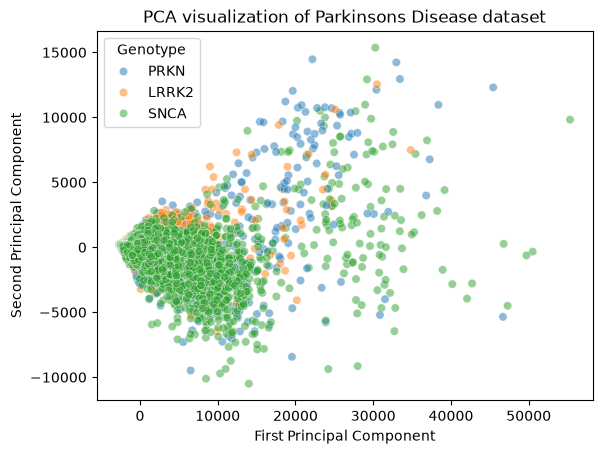

In [27]:
# fig = pyplot.scatter(x=x_pca[:, 0], y=x_pca[:, 1], color=y)

full_df = pd.DataFrame(data=x_pca, columns=['Principal Component 1', 'Principal Component 2','Principal Component 3', 'Principal Component 4'])
full_df['Genotype'] = y
# fig = px.scatter(x=x_pca[:, 0], y=x_pca[:, 1], color=y)
# full_df.head()
fig = sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Genotype',
    data=full_df,
    alpha=0.5
)


fig.set_title('PCA visualization of Parkinson''s Disease dataset')

fig.set_xlabel('First Principal Component')
fig.set_ylabel('Second Principal Component')


Text(0, 0.5, 'Fourth Principal Component')

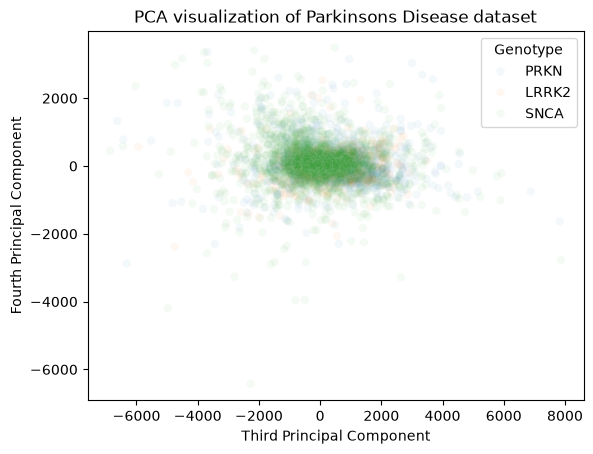

In [19]:
fig = sns.scatterplot(
    x='Principal Component 3',
    y='Principal Component 4',
    hue='Genotype',
    data=full_df,
    alpha=0.05
)


fig.set_title('PCA visualization of Parkinson''s Disease dataset')

fig.set_xlabel('Third Principal Component')
fig.set_ylabel('Fourth Principal Component')

Text(0, 0.5, 'Fourth Principal Component')

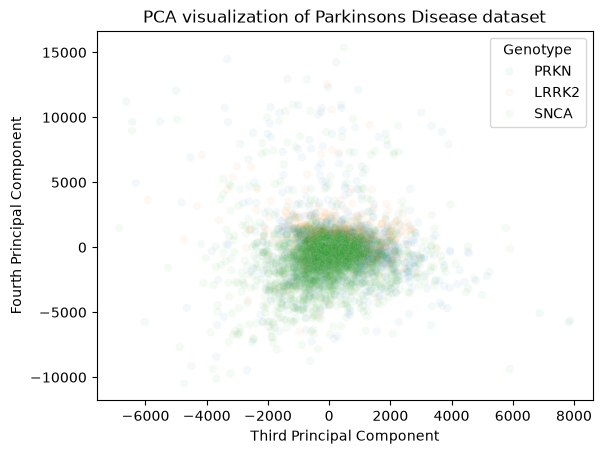

In [ ]:
fig = sns.scatterplot(
    x='Principal Component 3',
    y='Principal Component 2',
    hue='Genotype',
    data=full_df,
    alpha=0.05
)


fig.set_title('PCA visualization of Parkinson''s Disease dataset')

fig.set_xlabel('Third Principal Component')
fig.set_ylabel('Second Principal Component')

## TSNE

In [29]:
tsne = TSNE(n_components=2, random_state=42)
input_df = full_df[['Principal Component 1', 'Principal Component 2','Principal Component 3', 'Principal Component 4']]
output_df = full_df[['Genotype']]
X_tsne = tsne.fit_transform(input_df)
tsne.kl_divergence_

1.7126108407974243

Text(0, 0.5, 'Second t-SNE')

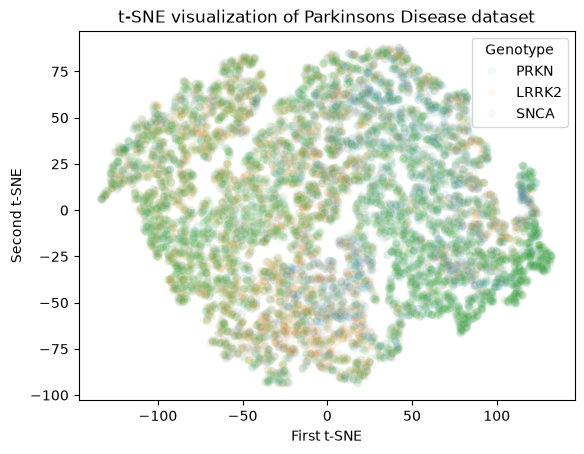

In [32]:
# fig = pyplot.scatter(x=x_pca[:, 0], y=x_pca[:, 1], color=y)


full_df = pd.DataFrame(data=X_tsne, columns=['First t-SNE', 'Second t-SNE'])
full_df['Genotype'] = y
fig = sns.scatterplot(
    x='First t-SNE',
    y='Second t-SNE',
    hue='Genotype',
    data=full_df,
    alpha=0.05
)


fig.set_title('t-SNE visualization of Parkinson''s Disease dataset')

fig.set_xlabel('First t-SNE')
fig.set_ylabel('Second t-SNE')



# Correlation

In [23]:
# combined_features = tmrm_df.merge(mtg_df, on='Cellline ID')
# combined_features.head()

In [24]:
# sns.scatterplot(
#     data=combined_features,
#     x='Mitochondria Intensity - Nucleus region Mean_x',
#     y='Mitochondria Intensity - Nucleus region Mean_y',
#     hue='Cell Type_x'
# )